Import nessesary libraries and packages

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Read csv file with data from 2018. Ironman

In [7]:
path = '/content/drive/MyDrive/Colab Notebooks/data/data_2018_lin_reg.csv'
df_2018 = pd.read_csv(path)

df_2018.head()

,Unnamed: 0,run_2018,overall_2018
0,0,2.848889,8.410000
1,1,3.088056,8.566944
2,2,3.042778,8.613333
3,3,3.053611,8.620833
4,4,3.083889,8.624167


In [8]:
x_2018, y_2018 = df_2018['run_2018'].values, df_2018['overall_2018'].values

Visualize data

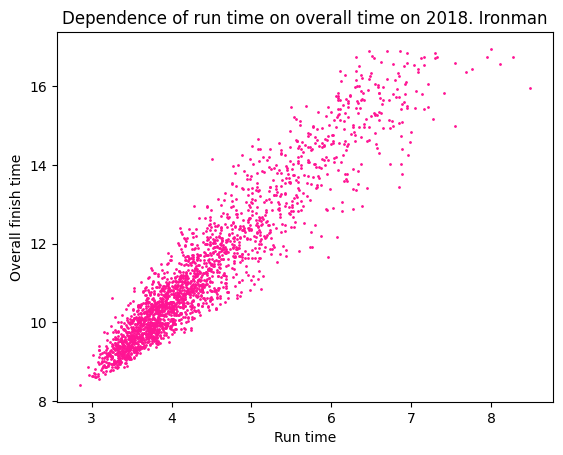

In [9]:
plt.figure()
plt.scatter(x_2018, y_2018, color='deeppink', s=1)
plt.xlabel('Run time')
plt.ylabel('Overall finish time')
plt.title('Dependence of run time on overall time on 2018. Ironman')
plt.show()

# Choose the prior or alpha_x

We will use normal prior for alpha_x

Let's decide on prior mean and standard deviation

In [15]:
x_mean = np.mean(x_2018)
y_mean = np.mean(y_2018)

In [16]:
mean_prior_alpha_x = y_mean
mean_prior_alpha_x

11.239965559563169

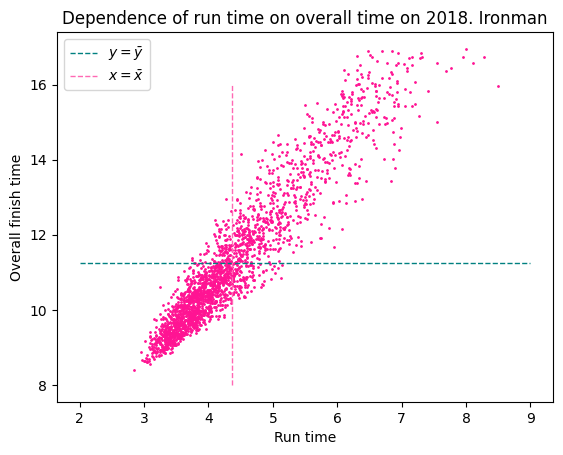

In [17]:
plt.figure()
plt.scatter(x_2018, y_2018, color='deeppink', s=1)
plt.xlabel('Run time')
plt.ylabel('Overall finish time')
plt.title('Dependence of run time on overall time on 2018. Ironman')
plt.plot([2, 9], [y_mean, y_mean], '--', linewidth=1, color='teal', label=r'$y = \bar{y}$')
plt.plot([x_mean, x_mean], [8, 16], '--', linewidth=1, color='hotpink', label=r'$x = \bar{x}$')
plt.legend()
plt.show()

In [13]:
lower_bound_alpha_x, upper_bound_alpha_x = 9.5, 13.5
std_prior_alpha_x = (upper_bound_alpha_x - lower_bound_alpha_x) / 6
std_prior_alpha_x

0.6666666666666666

Visualize prior bounds for alpha_x

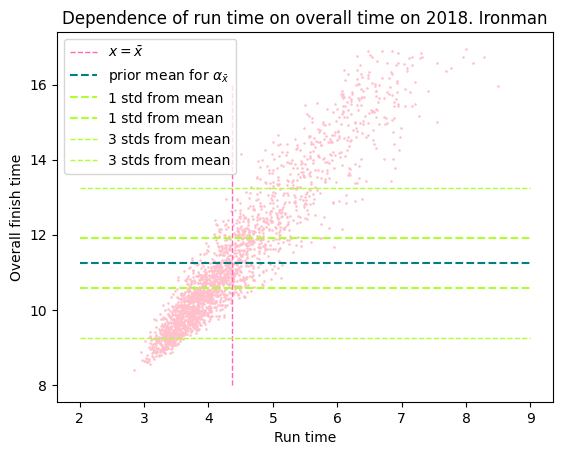

In [18]:
plt.figure()
plt.scatter(x_2018, y_2018, color='pink', s=.7)
plt.xlabel('Run time')
plt.ylabel('Overall finish time')
plt.title('Dependence of run time on overall time on 2018. Ironman')

plt.plot([x_mean, x_mean], [8, 16], '--', linewidth=1, color='hotpink', label=r'$x = \bar{x}$')
plt.plot([2, 9], [y_mean, y_mean], '--', linewidth=1.5, color='teal', label=r'prior mean for $\alpha_{\bar{x}}$')

plt.plot([2, 9], [11.24 + std_prior_alpha_x, 11.24 + std_prior_alpha_x], '--', linewidth=1.5, color='greenyellow', label=r'1 std from mean')
plt.plot([2, 9], [11.24 - std_prior_alpha_x, 11.24 - std_prior_alpha_x], '--', linewidth=1.5, color='greenyellow', label=r'1 std from mean')
plt.plot([2, 9], [11.24 + 3*std_prior_alpha_x, 11.24 + 3*std_prior_alpha_x], '--', linewidth=1, color='greenyellow', label=r'3 stds from mean')
plt.plot([2, 9], [11.24 - 3*std_prior_alpha_x, 11.24 - 3*std_prior_alpha_x], '--', linewidth=1, color='greenyellow', label=r'3 stds from mean')

plt.legend()
plt.show()

# Choose prior for beta

We will use normal prior for beta

In [22]:
mean_prior_beta = (np.mean(x_2018*y_2018) - np.mean(x_2018) * np.mean(y_2018))\
                  / (np.mean(x_2018**2) - x_mean**2)
mean_prior_beta

1.8535035966136237

In [ ]:
std_prior_beta = 1/3

Visualize prior bounds for beta


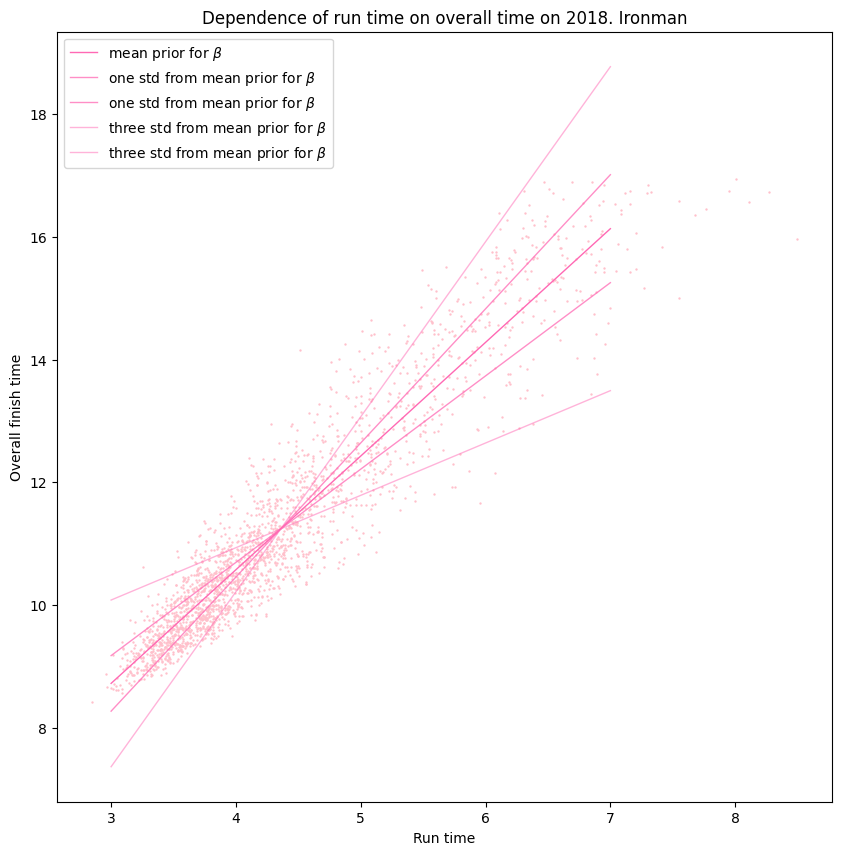

In [23]:
plt.figure(figsize=(10, 10))

plt.scatter(x_2018, y_2018, color='pink', s=.5)

plt.xlabel('Run time')
plt.ylabel('Overall finish time')
plt.title('Dependence of run time on overall time on 2018. Ironman')

x_plot = np.array([3, 7])
y = mean_prior_beta * (x_plot - x_mean) + mean_prior_alpha_x
plt.plot(x_plot, y, linewidth=1, color='hotpink',
         label=r'mean prior for $\beta$', alpha=1)
y_1std_p = (mean_prior_beta + std_prior_beta)*(x_plot - x_mean) + mean_prior_alpha_x
plt.plot(x_plot, y_1std_p, linewidth=1, color='hotpink',
         label=r'one std from mean prior for $\beta$', alpha=.75)
y_1std_m = (mean_prior_beta - std_prior_beta)*(x_plot - x_mean) + mean_prior_alpha_x
plt.plot(x_plot, y_1std_m, linewidth=1, color='hotpink',
         label=r'one std from mean prior for $\beta$', alpha=.75)
y_3std_p = (mean_prior_beta + 3*std_prior_beta)*(x_plot - x_mean) + mean_prior_alpha_x
plt.plot(x_plot, y_3std_p, linewidth=1, color='hotpink',
         label=r'three std from mean prior for $\beta$', alpha=.5)
y_3std_m = (mean_prior_beta - 3*std_prior_beta)*(x_plot - x_mean) + mean_prior_alpha_x
plt.plot(x_plot, y_3std_m, linewidth=1, color='hotpink',
         label=r'three std from mean prior for $\beta$', alpha=.5)
plt.legend()
plt.show()